In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
food = pd.read_csv("/content/daily_food_nutrition_dataset.csv", on_bad_lines='skip')
print(food.head())

                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   
3                       Banana          Fruit              105          1.3   
4        Grilled Chicken Salad   Meal/Protein              350         30.0   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         0.0            5   
3               27.0      0.4        3.1        14.0            1   
4               10.0     20.0        5.0         4.0          400   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0               370  Breakfast                250  
1     

In [ ]:
food = food.dropna()


In [ ]:
le = LabelEncoder()

for col in food.columns:
    if food[col].dtype == 'object':
        food[col] = le.fit_transform(food[col])


In [ ]:
height = float(input("Enter height in meters: "))
weight = float(input("Enter weight in kg: "))


Enter height in meters: 1.7
Enter weight in kg: 70


In [ ]:
bmi = weight / (height ** 2)
print("Your BMI:", round(bmi,2))


Your BMI: 24.22


In [ ]:
def obesity_level(bmi):

    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

level = obesity_level(bmi)
print("Obesity Level:", level)


Obesity Level: Normal


In [ ]:
food.rename(columns={"Food_Item": "food"}, inplace=True)
food.rename(columns={"Calories (kcal)": "Calories"}, inplace=True)


In [ ]:
def recommend_food(level):

    if level == "Underweight":
        rec = food[food["Calories"] > 400]

    elif level == "Normal":
        rec = food[(food["Calories"] >= 300) & (food["Calories"] <= 500)]

    elif level == "Overweight":
        rec = food[food["Calories"] < 350]

    else:   # Obese
        rec = food[(food["Calories"] < 300) & (food["Fiber"] > 3)]

    print("\nRecommended Foods:\n")
    print(rec.head(10))

recommend_food(level)



Recommended Foods:

                            food             Category  Calories  Protein (g)  \
4          Grilled Chicken Salad         Meal/Protein       350         30.0   
13    Turkey Sandwich (on wheat)       Meal/Processed       340         22.0   
15           Spaghetti Bolognese           Meal/Pasta       460         20.0   
21                 Tofu Stir-fry      Meal/Vegetarian       400         18.0   
33  Chicken Wrap (with tortilla)       Meal/Processed       410         25.0   
37         French Fries (medium)  Vegetable/Processed       340          4.0   
63   Caesar Salad (with chicken)         Meal/Protein       470         30.0   
75     Macaroni & Cheese (1 cup)           Meal/Pasta       350         10.0   
77       Grilled Cheese Sandwich       Meal/Processed       390         15.0   
78     Beef Tacos (2 hard shell)            Meal/Meat       380         18.0   

    Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
4                10.0     20

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

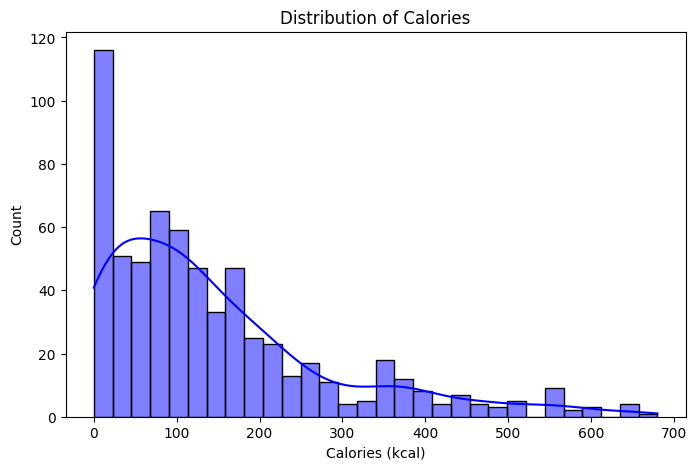

In [ ]:
plt.figure(figsize=(8, 5))
food.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.histplot(food['Calories (kcal)'], bins=30, kde=True, color='blue')
plt.title('Distribution of Calories')
plt.xlabel('Calories (kcal)');plt.ylabel('Count')
plt.show()

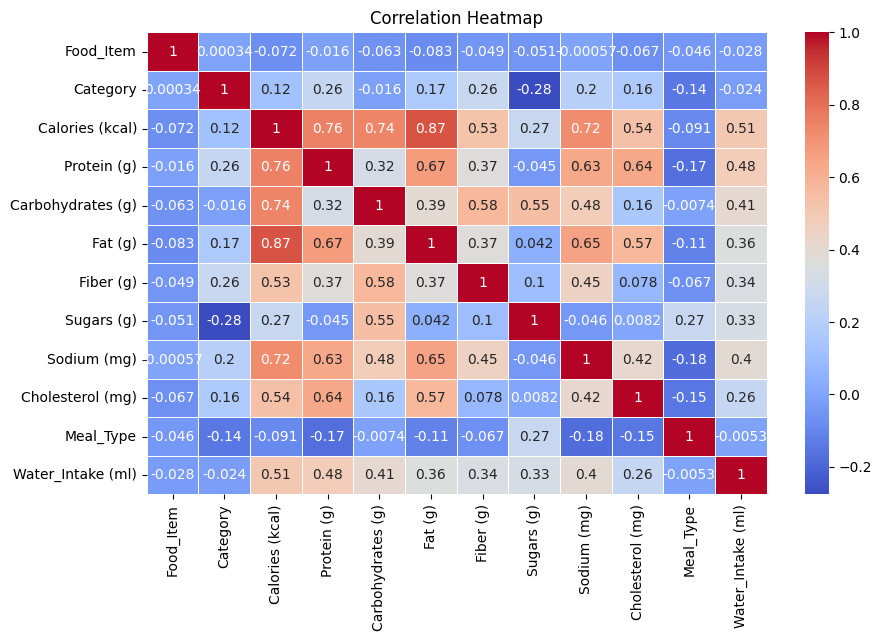

In [ ]:
food_numeric = food.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(food_numeric.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipython-input-822527458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Meal_Type', y='Calories (kcal)', data=food, palette='Set2')


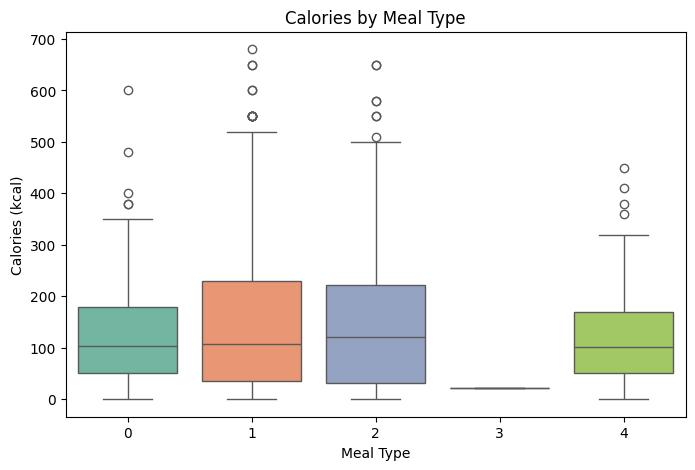

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Meal_Type', y='Calories (kcal)', data=food, palette='Set2')
plt.title('Calories by Meal Type')
plt.xlabel('Meal Type');plt.ylabel('Calories (kcal)')
plt.show()